Francisco Benita, 2026

# Urban Morphology Optimization - Data Loading & Filtering

This notebook handles the acquisition and preprocessing of 50m hexagonal grid datasets for Mexican metro areas.

In [ ]:
!pip install geopandas matplotlib mapclassify contextily

In [ ]:
import os
import requests
import geopandas as gpd
import matplotlib.pyplot as plt

# Define URLs
data_urls = {
    'cdmx': 'https://www.dropbox.com/scl/fi/wxps4aijd4mf2jmji0j0n/ciudad_de_mexico_final_results.gpkg?rlkey=8k7904o43fe7d66v4vcgdeya2&dl=1',
    'monterrey': 'https://www.dropbox.com/scl/fi/hss7xxnfrl8fwk4prupvr/monterrey_final_results.gpkg?rlkey=6kri4ejs5juhpm9l699nkg5j1&dl=1',
    'zacatecas': 'https://www.dropbox.com/scl/fi/mtw6yanftigtyafoc493l/zacatecas_guadalupe_final_results.gpkg?rlkey=uibkahfz9i55z4m5idn3r84ou&dl=1'
}

# Download files
for city, url in data_urls.items():
    filename = f"{city}_results.gpkg"
    if not os.path.exists(filename):
        print(f"Downloading {city}...")
        r = requests.get(url, allow_redirects=True)
        with open(filename, 'wb') as f:
            f.write(r.content)
    else:
        print(f"{city} already exists.")

In [ ]:
# Load Monterrey Data
mty_gdf = gpd.read_file('monterrey_results.gpkg')

initial_rows = len(mty_gdf)
print(f"Initial number of hexagons: {initial_rows}")

# Filter for walkable urban footprint
# Drop rows where population is null/0 OR network_density is null
mty_filtered = mty_gdf[
    (mty_gdf['population_count_1_2km'].notnull()) &
    (mty_gdf['population_count_1_2km'] > 0) &
    (mty_gdf['network_density_1_2km'].notnull())
].copy()

final_rows = len(mty_filtered)
print(f"Filtered number of hexagons: {final_rows}")
print(f"Removed {initial_rows - final_rows} non-urban/invalid cells.")

display(mty_filtered.head())

Initial number of hexagons: 1140842
Filtered number of hexagons: 303782
Removed 837060 non-urban/invalid cells.


,CVEGEO,CVE_ENT,CVE_MUN,NOMGEO,CVE_MET,NOM_MET,TIPO_MET,area,id,x,...,food_inegi_count_1_2km,healthcare_osm_count_1_2km,healthcare_inegi_count_1_2km,educational_osm_count_1_2km,educational_inegi_count_1_2km,leisure_osm_count_1_2km,leisure_inegi_count_1_2km,amenity_diversity_osm,amenity_diversity_inegi,geometry
10146,19006,19,006,Apodaca,19.1.01,Monterrey,Zona metropolitana,6495.190528,10147.0,318609.54798,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((318634.548 2867580.594, 318584.548 2..."
10147,19006,19,006,Apodaca,19.1.01,Monterrey,Zona metropolitana,6495.190528,10148.0,318609.54798,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((318634.548 2867667.196, 318584.548 2..."
10417,19006,19,006,Apodaca,19.1.01,Monterrey,Zona metropolitana,6495.190528,10418.0,318684.54798,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((318709.548 2867450.69, 318659.548 28..."
10418,19006,19,006,Apodaca,19.1.01,Monterrey,Zona metropolitana,6495.190528,10419.0,318684.54798,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((318709.548 2867537.292, 318659.548 2..."
10419,19006,19,006,Apodaca,19.1.01,Monterrey,Zona metropolitana,6495.190528,10420.0,318684.54798,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((318709.548 2867623.895, 318659.548 2..."


# Phase 1: Data Preparation & Surrogate Model Training




Data Ingestion and Spatial Weights

In [ ]:
import numpy as np
import geopandas as gpd
import scipy.sparse as sparse
from scipy.spatial import cKDTree
import gc

# Ensure data is loaded if it's missing from memory
try:
    mty_filtered
except NameError:
    print("Reloading and filtering Monterrey data...")
    mty_gdf = gpd.read_file('monterrey_results.gpkg')
    mty_filtered = mty_gdf[
        (mty_gdf['population_count_1_2km'] > 0) &
        (mty_gdf['network_density_1_2km'].notnull())
    ].copy().reset_index(drop=True)

# 1. Define Variable Sets
primitive_cols = ['food_osm_count_1_2km', 'healthcare_osm_count_1_2km', 'educational_osm_count_1_2km', 'leisure_osm_count_1_2km', 'population_count_1_2km']
derived_cols = ['network_density_1_2km', 'intersection_density_ge3_1_2km', 'amenity_diversity_osm', 'average_link_length_1_2km']

# 2. Extract Centroids efficiently
print("Extracting centroids...")
coords = np.column_stack((mty_filtered.geometry.centroid.x, mty_filtered.geometry.centroid.y))

# 3. Build the Main KDTree
print("Building main KDTree...")
main_tree = cKDTree(coords)

# 4. Compute Spatial Weights in Batches to prevent RAM crashes
batch_size = 10000
n_points = coords.shape[0]
A_matrices = []

print(f"Computing sparse diffusion matrix in batches of {batch_size}...")

for i in range(0, n_points, batch_size):
    end = min(i + batch_size, n_points)
    print(f"Processing rows {i} to {end}...")

    # Build a temporary tree for just this batch of points
    batch_tree = cKDTree(coords[i:end])

    # Compute distances from this batch to the entire grid
    raw_dist_mat = batch_tree.sparse_distance_matrix(main_tree, max_distance=1200)

    # Convert explicitly to COO format to expose the .data attribute
    dist_mat = raw_dist_mat.tocoo()

    # Apply morphological distance decay: max(0, 1 - d/1200)
    # Cast to float32 to instantly cut RAM usage in half
    dist_mat.data = (1.0 - (dist_mat.data / 1200.0)).astype(np.float32)

    # Convert to Compressed Sparse Row (CSR) immediately to shrink memory footprint
    A_matrices.append(dist_mat.tocsr())

    # Force garbage collection to free up the uncompressed intermediate RAM
    del batch_tree
    del raw_dist_mat
    del dist_mat
    gc.collect()

# 5. Assemble Final Matrix
print("Stacking batches into final sparse matrix...")
A_sparse = sparse.vstack(A_matrices)

# Force the diagonal to 1.0 (decay at 0 distance)
A_sparse.setdiag(1.0)

print(f"\nSuccess!")
print(f"Final Matrix Shape: {A_sparse.shape}")
print(f"Non-zero elements: {A_sparse.nnz}")

Extracting centroids...
Building main KDTree...
Computing sparse diffusion matrix in batches of 10000...
Processing rows 0 to 10000...
Processing rows 10000 to 20000...
Processing rows 20000 to 30000...
Processing rows 30000 to 40000...
Processing rows 40000 to 50000...
Processing rows 50000 to 60000...
Processing rows 60000 to 70000...
Processing rows 70000 to 80000...
Processing rows 80000 to 90000...
Processing rows 90000 to 100000...
Processing rows 100000 to 110000...
Processing rows 110000 to 120000...
Processing rows 120000 to 130000...
Processing rows 130000 to 140000...
Processing rows 140000 to 150000...
Processing rows 150000 to 160000...
Processing rows 160000 to 170000...
Processing rows 170000 to 180000...
Processing rows 180000 to 190000...
Processing rows 190000 to 200000...
Processing rows 200000 to 210000...
Processing rows 210000 to 220000...
Processing rows 220000 to 230000...
Processing rows 230000 to 240000...
Processing rows 240000 to 250000...
Processing rows 25

In [ ]:
!pip install pygam

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 4.8 MB/s eta 0:00:00


### Target Calculation (SUMI) using Entropy Weights
We normalize the derived indicators, compute their entropy, and derive weights to create a composite walkability score.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# 1. Prepare derived variables
derived_data = mty_filtered[derived_cols].copy()

# Invert average_link_length (shorter is better for walkability)
derived_data['average_link_length_1_2km'] = 1 / (derived_data['average_link_length_1_2km'] + 1)

# 2. Entropy Weight Method
scaler = MinMaxScaler(feature_range=(0.001, 1)) # Avoid 0 for log calculation
scaled_derived = scaler.fit_transform(derived_data)

# Compute probability matrix
p_ij = scaled_derived / scaled_derived.sum(axis=0)

# Compute entropy
k = 1 / np.log(len(mty_filtered))
e_j = -k * (p_ij * np.log(p_ij)).sum(axis=0)

# Compute weights
d_j = 1 - e_j
weights = d_j / d_j.sum()

print("Computed Entropy Weights:")
for col, w in zip(derived_cols, weights):
    print(f" - {col}: {w:.4f}")

# 3. Create Target SUMI
mty_filtered['target_sumi'] = (scaled_derived * weights).sum(axis=1)
display(mty_filtered[['target_sumi']].describe())

Computed Entropy Weights:
 - network_density_1_2km: 0.1492
 - intersection_density_ge3_1_2km: 0.2717
 - amenity_diversity_osm: 0.4970
 - average_link_length_1_2km: 0.0822


,target_sumi
count,303782.000000
mean,0.296082
std,0.287271
min,0.003588
25%,0.045842
50%,0.133438
75%,0.580875
max,0.916936


### Surrogate Model Training (LinearGAM)
We apply monotonic increasing constraints to amenity counts to enforce diminishing returns.

In [ ]:
from pygam import LinearGAM, s, f
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score

# X: Primitive variables, y: SUMI target
X = mty_filtered[primitive_cols].values
y = mty_filtered['target_sumi'].values

# Define GAM: s() for spline terms
# index 0-3 are amenities (food, healthcare, edu, leisure) -> monotonic inc
# index 4 is population
gam = LinearGAM(
    s(0, constraints='monotonic_inc') +
    s(1, constraints='monotonic_inc') +
    s(2, constraints='monotonic_inc') +
    s(3, constraints='monotonic_inc') +
    s(4)
)

# 5-Fold Cross Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = []

print("Starting 5-fold Cross-Validation...")
for train_idx, test_idx in kf.split(X):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Fit and score
    gam.fit(X_train, y_train)
    y_pred = gam.predict(X_test)
    scores.append(r2_score(y_test, y_pred))

print(f"\nAverage Out-of-Sample R2: {np.mean(scores):.4f} (+/- {np.std(scores):.4f})")

# Final fit on full data for optimization
gam.fit(X, y)
print("\nFinal Model Summary:")
print(gam.summary())

Starting 5-fold Cross-Validation...

Average Out-of-Sample R2: 0.9656 (+/- 0.0003)

Final Model Summary:
LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     34.9324
Link Function:                     IdentityLink Log Likelihood:                                 459723.449
Number of Samples:                       303782 AIC:                                          -919375.0331
                                                AICc:                                         -919375.0244
                                                GCV:                                                0.0028
                                                Scale:                                              0.0533
                                       

/tmp/ipykernel_1109/2853971099.py:39: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(gam.summary())


# Phase 2: The Lazy Greedy Optimization Engine

In [ ]:
import numpy as np
import heapq
import time
from tqdm import tqdm
import scipy.sparse as sparse

def lazy_greedy_omgl(A_sparse, gam, budget, df, primitive_cols, delta_vector, num_candidates=10000):
    print("1. Converting diffusion matrix to CSC format for high-speed column slicing...")
    A_csc = A_sparse.tocsc()

    print("2. Extracting baseline state and population...")
    V_initial = df[primitive_cols].values.astype(np.float32)
    population = df['population_count_1_2km'].values.astype(np.float32)
    N = V_initial.shape[0]

    # Smart Pruning: Prioritize walkability deserts with high population
    print("3. Executing Smart Pruning (Deficit Priority Ranking)...")
    baseline_scores = df['target_sumi'].values
    max_score = np.max(baseline_scores)
    # Deficit = distance to max walkability score weighted by population density
    deficit_score = population * (max_score - baseline_scores)

    # Select the top N highest priority candidate cells
    candidate_indices = np.argsort(deficit_score)[::-1][:num_candidates]

    current_V = V_initial.copy()

    # --- FAST LOCALIZED MARGINAL GAIN FUNCTION ---
    def get_marginal_gain(j, V_state):
        start_idx = A_csc.indptr[j]
        end_idx = A_csc.indptr[j+1]
        neighbors = A_csc.indices[start_idx:end_idx]
        decay_vals = A_csc.data[start_idx:end_idx]

        if len(neighbors) == 0:
            return 0.0

        V_old = V_state[neighbors]
        V_new = V_old + np.outer(decay_vals, delta_vector)

        pop_affected = population[neighbors]
        u_old = gam.predict(V_old) * pop_affected
        u_new = gam.predict(V_new) * pop_affected

        return np.sum(u_new - u_old)

    # --- HEAP INITIALIZATION ---
    print(f"4. Initializing Priority Queue for {num_candidates} priority candidates...")
    pq = []
    for j in tqdm(candidate_indices, desc="Initializing Heap"):
        gain = get_marginal_gain(j, current_V)
        if gain > 0:
            heapq.heappush(pq, (-gain, j))

    # --- BASELINE OBJECTIVE ---
    print("5. Calculating initial global objective...")
    current_obj = np.sum(gam.predict(current_V) * population)
    history_objective = [current_obj]
    selected_interventions = []

    # --- LAZY GREEDY SEARCH ---
    print(f"6. Starting Lazy Greedy search for B={budget}...")
    start_time = time.time()

    for step in range(budget):
        if not pq:
            print("No more candidates with positive gain.")
            break

        while True:
            neg_gain, j = heapq.heappop(pq)

            # Re-evaluate exact marginal gain under the CURRENT state
            actual_gain = get_marginal_gain(j, current_V)

            # Matroid/Submodularity check
            if len(pq) == 0 or actual_gain >= -pq[0][0]:
                selected_interventions.append(j)
                current_obj += actual_gain
                history_objective.append(current_obj)

                # Permanently update the global state
                start_idx = A_csc.indptr[j]
                end_idx = A_csc.indptr[j+1]
                neighbors = A_csc.indices[start_idx:end_idx]
                decay_vals = A_csc.data[start_idx:end_idx]

                current_V[neighbors] += np.outer(decay_vals, delta_vector)
                break
            else:
                heapq.heappush(pq, (-actual_gain, j))

    elapsed = time.time() - start_time
    print(f"Optimization complete in {elapsed:.2f} seconds.")
    return selected_interventions, history_objective

# --- DEFINING STANDARDIZED ENGINEERING INTERVENTIONS ---
# Schema: ['food_osm_count_1_2km', 'healthcare_osm_count_1_2km', 'educational_osm_count_1_2km', 'leisure_osm_count_1_2km', 'population_count_1_2km']
# Intervention: Mixed-Use Community Hub (+1 Food/Commerce POI, +1 Leisure/Green Space POI)
delta_community_hub = np.array([1, 0, 0, 1, 0], dtype=np.float32)

In [ ]:
import matplotlib.pyplot as plt

print("========================================================")
print("RUNNING EXPERIMENT 1: SPATIAL INTERACTION ABLATION")
print("========================================================")

# Run Run 1: True Spatial Diffusion Matrix (A)
print("\n--- Execution 1: Running OMGL with Graph Diffusion ---")
nodes_A, history_A = lazy_greedy_omgl(
    A_sparse=A_sparse,
    gam=gam,
    budget=50,
    df=mty_filtered,
    primitive_cols=primitive_cols,
    delta_vector=delta_community_hub,
    num_candidates=10000
)

# Run Run 2: Spatial Spillovers Disabled (A = Identity Matrix)
print("\n--- Execution 2: Running Ablation with Identity Matrix (No Diffusion) ---")
I_sparse = sparse.eye(len(mty_filtered), format='csr')
nodes_I, history_I = lazy_greedy_omgl(
    A_sparse=I_sparse,
    gam=gam,
    budget=50,
    df=mty_filtered,
    primitive_cols=primitive_cols,
    delta_vector=delta_community_hub,
    num_candidates=10000
)

# --- CALCULATING PERFORMANCE METRICS ---
baseline_score = history_I[0]
value_added_I = history_I[-1] - baseline_score
value_added_A = history_A[-1] - baseline_score
roi_multiplier = value_added_A / value_added_I if value_added_I > 0 else 0

print("\n========================================================")
print("EXPERIMENTAL METRICS FOR MANUSCRIPT TEXT")
print("========================================================")
print(f"Baseline Metropolitan Score:          {baseline_score:,.2f}")
print(f"Marginal Value Added (No Diffusion):  {value_added_I:,.2f}")
print(f"Marginal Value Added (With Diffusion): {value_added_A:,.2f}")
print(f"Net Intervention ROI Multiplier:      {roi_multiplier:.2f}x increase")
print(f"Absolute Metropolitan Improvement:     {((history_A[-1]/baseline_score)-1)*100:.4f}%")



RUNNING EXPERIMENT 1: SPATIAL INTERACTION ABLATION

--- Execution 1: Running OMGL with Graph Diffusion ---
1. Converting diffusion matrix to CSC format for high-speed column slicing...
2. Extracting baseline state and population...
3. Executing Smart Pruning (Deficit Priority Ranking)...
4. Initializing Priority Queue for 10000 priority candidates...


Initializing Heap: 100%|██████████| 10000/10000 [02:24<00:00, 69.03it/s]


5. Calculating initial global objective...
6. Starting Lazy Greedy search for B=50...
Optimization complete in 160.15 seconds.

--- Execution 2: Running Ablation with Identity Matrix (No Diffusion) ---
1. Converting diffusion matrix to CSC format for high-speed column slicing...
2. Extracting baseline state and population...
3. Executing Smart Pruning (Deficit Priority Ranking)...
4. Initializing Priority Queue for 10000 priority candidates...


Initializing Heap: 100%|██████████| 10000/10000 [01:01<00:00, 162.44it/s]


5. Calculating initial global objective...
6. Starting Lazy Greedy search for B=50...
Optimization complete in 0.22 seconds.

EXPERIMENTAL METRICS FOR MANUSCRIPT TEXT
Baseline Metropolitan Score:          1,997,313,535.39
Marginal Value Added (No Diffusion):  382,038.84
Marginal Value Added (With Diffusion): 51,303,968.34
Net Intervention ROI Multiplier:      134.29x increase
Absolute Metropolitan Improvement:     2.5686%



GENERATING EXPERIMENT 2 FIGURES: BUDGET SENSITIVITY


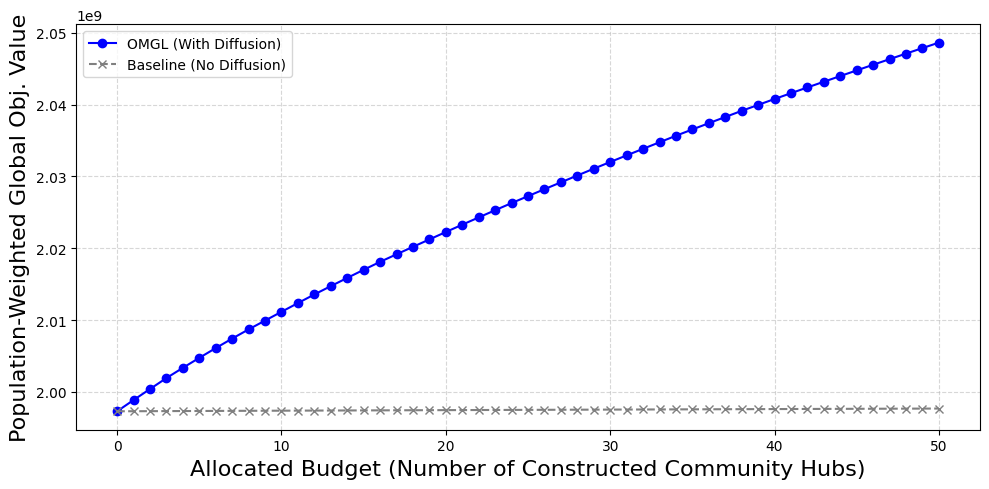

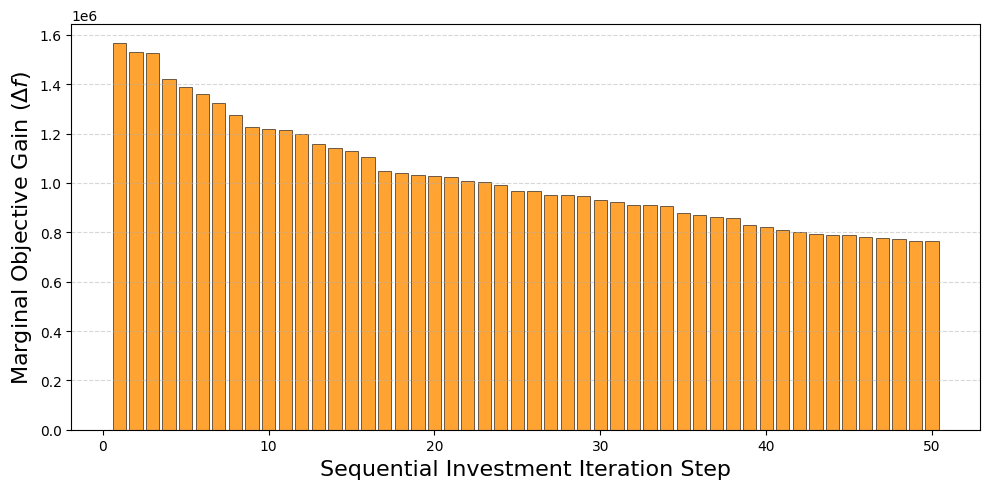

In [ ]:
# ========================================================$
print("\nGENERATING EXPERIMENT 2 FIGURES: BUDGET SENSITIVITY")
print("========================================================")

# Figure: Total Utility Progression
plt.figure(figsize=(10, 5), facecolor='white')
plt.plot(range(0, len(history_A)), history_A, marker='o', linestyle='-', color='b', label='OMGL (With Diffusion)')
plt.plot(range(0, len(history_I)), history_I, marker='x', linestyle='--', color='gray', label='Baseline (No Diffusion)')
#plt.title('Figure: Total Urban Utility vs. Capital Budget Allocation ($B$)', fontsize=18)
plt.xlabel('Allocated Budget (Number of Constructed Community Hubs)', fontsize=16)
plt.ylabel('Population-Weighted Global Obj. Value', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig("Total Utility.png", dpi=300, format="png")
plt.show()

# Figure: Marginal Utility Gains (Staircase Proof of Submodularity)
marginal_gains = np.diff(history_A)
plt.figure(figsize=(10, 5), facecolor='white')
plt.bar(range(1, len(marginal_gains)+1), marginal_gains, color='darkorange', alpha=0.8, edgecolor='black', linewidth=0.5)
#plt.title('Figure: Empirical Verification of Monotone Submodularity (Diminishing Returns)', fontsize=18)
plt.xlabel('Sequential Investment Iteration Step', fontsize=16)
plt.ylabel(r'Marginal Objective Gain ($\Delta f$)', fontsize=16)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("Marginal Utility.png", dpi=300, format="png")
plt.show()

<>:41: SyntaxWarning: invalid escape sequence '\D'
<>:41: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_1109/4093911877.py:41: SyntaxWarning: invalid escape sequence '\D'
  axes[2].set_title('C. Predicted Spatial Impact ($\Delta \widehat{F}$)', fontsize=16, color='white')


Calculating spatial predictions for plotting...
Generating Maps...


/tmp/ipykernel_1109/4093911877.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


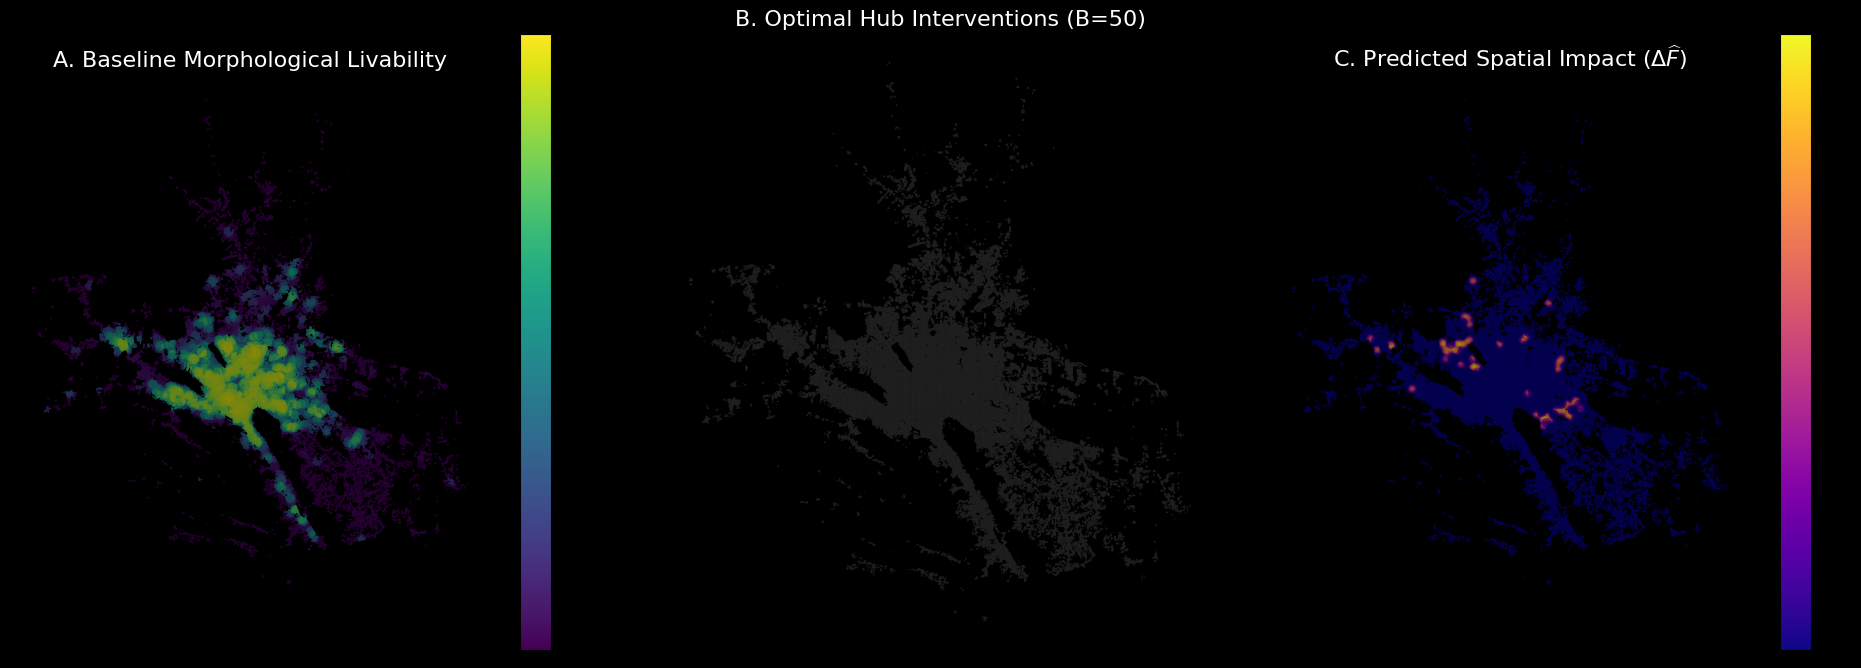

In [ ]:
import matplotlib.pyplot as plt

print("Calculating spatial predictions for plotting...")
baseline_predictions = gam.predict(mty_filtered[primitive_cols].values)

# Reconstruct the final state from the A_sparse run
final_V = mty_filtered[primitive_cols].values.copy()
for j in nodes_A:
    start_idx = A_sparse.indptr[j]
    end_idx = A_sparse.indptr[j+1]
    neighbors = A_sparse.indices[start_idx:end_idx]
    decay_vals = A_sparse.data[start_idx:end_idx]

    # Apply the Community Hub delta vector
    final_V[neighbors] += np.outer(decay_vals, delta_community_hub)

final_predictions = gam.predict(final_V)
impact_delta = final_predictions - baseline_predictions

# Attach to GeoDataFrame
mty_filtered['baseline_sumi'] = baseline_predictions
mty_filtered['impact_delta'] = impact_delta
selected_gdf = mty_filtered.iloc[nodes_A]

print("Generating Maps...")
fig, axes = plt.subplots(1, 3, figsize=(24, 8), gridspec_kw={'wspace': 0.05})

# Map 1: Baseline
mty_filtered.plot(column='baseline_sumi', cmap='viridis',
                  ax=axes[0], legend=True, alpha=0.9, markersize=1)
axes[0].set_title('A. Baseline Morphological Livability', fontsize=16, color='white')

# Map 2: Interventions (Red Dots)
mty_filtered.plot(color='gray', ax=axes[1], alpha=0.3, markersize=1)
selected_gdf.plot(color='red', ax=axes[1], markersize=15, edgecolor='black', linewidth=0.5)
axes[1].set_title(f'B. Optimal Hub Interventions (B=50)', fontsize=16, color='white')

# Map 3: Impact Diffusion
mty_filtered.plot(column='impact_delta', cmap='plasma',
                  ax=axes[2], legend=True, alpha=0.9, markersize=1)
axes[2].set_title('C. Predicted Spatial Impact ($\Delta \widehat{F}$)', fontsize=16, color='white')

# Clean up axes for a beautiful dark-mode map
for ax in axes:
    ax.set_axis_off()
    ax.set_facecolor('black')
fig.patch.set_facecolor('black')

plt.tight_layout()
plt.show()

#Export as gpkg

In [ ]:
import numpy as np
import geopandas as gpd

print("1. Preparing final attributes for spatial export...")
# Ensure baseline and impact vectors are calculated and attached
baseline_predictions = gam.predict(mty_filtered[primitive_cols].values)

final_V = mty_filtered[primitive_cols].values.copy()
for j in nodes_A:
    start_idx = A_sparse.indptr[j]
    end_idx = A_sparse.indptr[j+1]
    neighbors = A_sparse.indices[start_idx:end_idx]
    decay_vals = A_sparse.data[start_idx:end_idx]
    final_V[neighbors] += np.outer(decay_vals, delta_community_hub)

final_predictions = gam.predict(final_V)
impact_delta = final_predictions - baseline_predictions

# Map arrays back to the main dataframe
mty_filtered['baseline_sumi'] = baseline_predictions
mty_filtered['impact_delta'] = impact_delta

# Create a clear binary indicator for selected locations (1 = Selected, 0 = Not Selected)
mty_filtered['is_intervention'] = 0
# Use the filtered dataframe's index mapping to safely flag the exact optimal nodes
mty_filtered.iloc[nodes_A, mty_filtered.columns.get_loc('is_intervention')] = 1

print("2. Exporting to a standalone GeoPackage file...")
output_filename = 'monterrey_omgl_optimized_results.gpkg'
mty_filtered.to_file(output_filename, layer='mty_hexagons', driver='GPKG')

print(f"Success! File saved as {output_filename}")

# Trigger an automatic download from the Google Colab backend to your local browser
from google.colab import files
files.download(output_filename)

1. Preparing final attributes for spatial export...
2. Exporting to a standalone GeoPackage file...
Success! File saved as monterrey_omgl_optimized_results.gpkg


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# The Intervention Sequence Map

Generating Chronological Sequence Map...


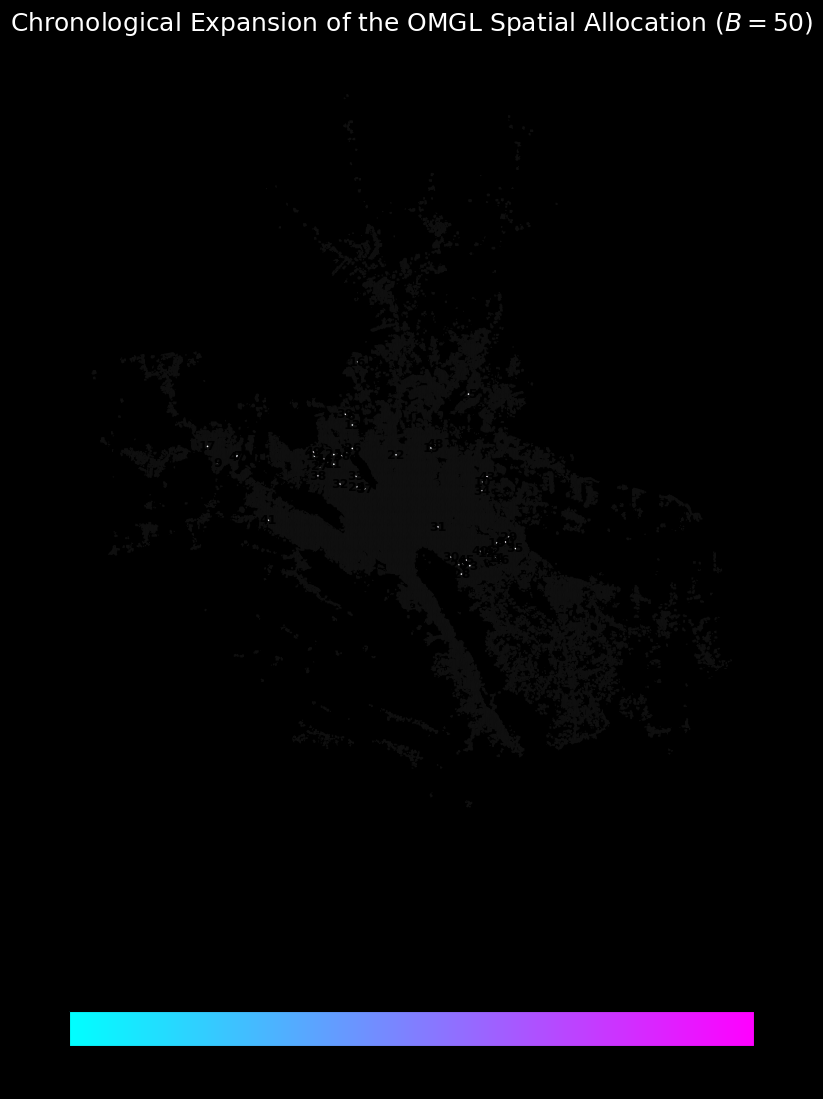

In [ ]:
import matplotlib.pyplot as plt

# 1. Create a clean GeoDataFrame for just the selected nodes
selected_gdf = mty_filtered.iloc[nodes_A].copy()
# 2. Add the sequence order (1 to 50)
selected_gdf['intervention_order'] = range(1, len(nodes_A) + 1)

print("Generating Chronological Sequence Map...")
fig, ax = plt.subplots(1, 1, figsize=(14, 12))

# Plot the baseline city footprint in dark, muted gray
mty_filtered.plot(ax=ax, color='#1a1a1a', edgecolor='none')

# Plot the 50 interventions using a sequential colormap (e.g., cyan to magenta)
scatter = selected_gdf.plot(
    column='intervention_order',
    cmap='cool',  # 'cool', 'spring', or 'plasma' work great on dark backgrounds
    ax=ax,
    markersize=250,
    edgecolor='white',
    linewidth=0.8,
    legend=True,
    legend_kwds={'label': "Greedy Selection Sequence (1 to 50)", 'orientation': "horizontal", 'shrink': 0.5}
)

# Annotate the sequence numbers directly inside the nodes
for x, y, label in zip(selected_gdf.geometry.centroid.x, selected_gdf.geometry.centroid.y, selected_gdf['intervention_order']):
    ax.annotate(str(label), xy=(x, y), xytext=(0, 0), textcoords="offset points",
                fontsize=9, ha='center', va='center', color='black', weight='bold')

# Formatting for a publication-ready look
ax.set_facecolor('black')
fig.patch.set_facecolor('black')
ax.set_axis_off()
plt.title('Chronological Expansion of the OMGL Spatial Allocation ($B=50$)', color='white', fontsize=18, pad=20)
plt.tight_layout()
plt.show()

In [ ]:
import geopandas as gpd
from google.colab import files

print("Preparing chronological sequence data for QGIS export...")

# 1. Isolate the exact 50 selected nodes into a new GeoDataFrame
selected_gdf = mty_filtered.iloc[nodes_A].copy()

# 2. Add the chronological sequence order (1 through 50)
selected_gdf['intervention_order'] = range(1, len(nodes_A) + 1)

# 3. Export to a dedicated GeoPackage
sequence_filename = 'monterrey_intervention_sequence.gpkg'
selected_gdf[['geometry', 'intervention_order']].to_file(sequence_filename, layer='intervention_sequence', driver='GPKG')

print(f"Success! File saved as {sequence_filename}")

# 4. Trigger automatic download
files.download(sequence_filename)

Preparing chronological sequence data for QGIS export...
Success! File saved as monterrey_intervention_sequence.gpkg


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>